In [42]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
import umap
from openTSNE import TSNE 

In [3]:
from openTSNE import TSNEEmbedding
from openTSNE import affinity
from openTSNE import initialization

In [4]:
from tqdm import tqdm

In [5]:
df_idotdo = pd.read_csv('ido1_tdo_fulljoin_20260205.csv')
df_idotdo

,molecule_chembl_id,smiles,ido1_ic50,tdo_ic50
0,CHEMBL412131,Cc1c(SC[C@H](NC(=O)CC[C@H](N)C(=O)O)C(=O)NCC(=...,340.0,NaN
1,CHEMBL565489,Cc1cccc(N/C(=N\O)c2nonc2N)c1,550.0,NaN
2,CHEMBL107103,O=C(c1ccccc1)c1cccc(O)c1,500000.0,NaN
3,CHEMBL3342385,CCOC(=O)c1cnc2scc(C3=CCCCC3)n12,100000.0,NaN
4,CHEMBL3765545,O=C1CCc2cc(S(=O)(=O)NNc3ccc(Br)cc3)ccc2N1,72.7,NaN
...,...,...,...,...
4586,CHEMBL6053460,N#Cc1cc(-c2c[nH]c3cc(F)ccc23)ccc1S(=O)(=O)N1CC...,NaN,730.0
4587,CHEMBL5819188,NC(=O)CNc1ccc(-c2c[nH]c3cc(F)ccc23)cn1,NaN,790.0
4588,CHEMBL4849018,OCC(O)Cn1nnc2ccc(-c3c[nH]c4ccccc34)cc21,NaN,25200.0
4589,CHEMBL4176841,Cc1ccn(-c2cnoc2N)n1,NaN,1600.0


In [6]:
df_tox21 = pd.read_csv('tox21.csv')
df_tox21

,smiles
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,CCN1C(=O)NC(c2ccccc2)C1=O
2,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,CC(O)(P(=O)(O)O)P(=O)(O)O
...,...
7826,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...
7827,CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...
7828,C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@@]43C)[C...
7829,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...


In [7]:
from rdkit.Chem import SaltRemover as sr
remover = sr.SaltRemover()
mols_tox21 = []
for i in range(len(df_tox21)):
    try:
        mol_i = Chem.MolFromSmiles(df_tox21['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols_tox21.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols_tox21.append(mol_i)
    except Exception as e:
        print(e)
len(mols_tox21)

[12:41:15] WARNING: not removing hydrogen atom without neighbors


7831

In [8]:
from rdkit.Chem import SaltRemover as sr
remover = sr.SaltRemover()
mols_idotdo = []
for i in range(len(df_idotdo)):
    try:
        mol_i = Chem.MolFromSmiles(df_idotdo['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols_idotdo.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols_idotdo.append(mol_i)
    except Exception as e:
        print(e)
len(mols_idotdo)

4591

In [9]:
import sys
from tqdm import tqdm
import os
import contextlib
#To suppress the output written messages. 
@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

FPs_idotdo = []
fpg = AllChem.GetMorganGenerator(radius=3, fpSize=1024) 
uncharger = rdMolStandardize.Uncharger()

for i in tqdm(range(len(df_idotdo))):
    try:
        with suppress_stdout_stderr():
            mol_i = Chem.MolFromSmiles(df_idotdo['smiles'][i])
            neutral_mol = uncharger.uncharge(mol_i)
            Chem.SanitizeMol(neutral_mol)
            fp = fpg.GetFingerprint(neutral_mol)
        FPs_idotdo.append(fp)
    except Exception as e:
        tqdm.write(f"An error occurred for molecule {i} as: {e}")

100%|████████████████████████████████████████████████████████████████████████| 4591/4591 [00:02<00:00, 1541.47it/s]


In [10]:
# To save the FPs as a numpy fromat
from rdkit.DataStructs import ConvertToNumpyArray

# Create empty NumPy array shape (num_fps, fp_size)
num_fps = len(FPs_idotdo)
fp_size = 1024  # your fingerprint size
arr_FPs_idotdo = np.zeros((num_fps, fp_size), dtype=np.uint8)

for i, fp in enumerate(FPs_idotdo):
    ConvertToNumpyArray(fp, arr_FPs_idotdo[i])

In [11]:
arr_FPs_idotdo.shape

(4591, 1024)

In [12]:
X1 = arr_FPs_idotdo

In [13]:
import contextlib
#To suppress the output written messages. 
@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

FPs_tox = []
fpg = AllChem.GetMorganGenerator(radius=3, fpSize=1024) 
uncharger = rdMolStandardize.Uncharger()

for i in tqdm(range(len(df_tox21))):
    try:
        with suppress_stdout_stderr():
            mol_i = Chem.MolFromSmiles(df_tox21['smiles'][i])
            neutral_mol = uncharger.uncharge(mol_i)
            Chem.SanitizeMol(neutral_mol)
            fp = fpg.GetFingerprint(neutral_mol)
        FPs_tox.append(fp)
    except Exception as e:
        tqdm.write(f"An error occurred for molecule {i} as: {e}")

 88%|███████████████████████████████████████████████████████████████▋        | 6926/7831 [00:02<00:00, 2297.67it/s]

An error occurred for molecule 6547 as: Explicit valence for atom # 0 Sb, 9, is greater than permitted


100%|████████████████████████████████████████████████████████████████████████| 7831/7831 [00:03<00:00, 2308.81it/s]


In [14]:
# To save the FPs as a numpy fromat
from rdkit.DataStructs import ConvertToNumpyArray

# Create empty NumPy array shape (num_fps, fp_size)
num_fps = len(FPs_tox)
fp_size = 1024  # your fingerprint size
tox_arr_FPs = np.zeros((num_fps, fp_size), dtype=np.uint8)

for i, fp in enumerate(FPs_tox):
    ConvertToNumpyArray(fp, tox_arr_FPs[i])

In [15]:
tox_arr_FPs.shape

(7830, 1024)

In [16]:
X2 = tox_arr_FPs

In [ ]:
#Loading ChEMBL and Drugbank fingerprints:

In [17]:
chembl = np.load('chembl36_FPs.npz')

In [18]:
X3 = chembl['fingerprints']

In [20]:
X3.shape

(2854798, 1024)

In [21]:
drugs = np.load('drugbank5_FPs.npz')

In [23]:
X4 = drugs['fingerprints']

In [24]:
X4.shape

(14606, 1024)

In [25]:
#Mapping:
#X1: ido_tdo
#X2: tox21
#X3: ChEMBL
#X4: Drugbank
X1.shape, X2.shape, X3.shape, X4.shape

((4591, 1024), (7830, 1024), (2854798, 1024), (14606, 1024))

In [26]:
np.random.seed(42)

In [27]:
#Initialize via downsampling in ChEMBL:
indices = np.random.permutation(list(range(X3.shape[0])))
reverse = np.argsort(indices)

x_sample, x_rest = X3[indices[:500000]], X3[indices[500000:]]

In [28]:
x_sample.shape, x_rest.shape

((500000, 1024), (2354798, 1024))

In [29]:
%%time
sample_affinities = affinity.PerplexityBasedNN(
    x_sample,
    perplexity=50,
    metric='cosine',
    n_jobs=32,
    random_state=42,
    verbose=True,
)

===> Finding 150 nearest neighbors using Annoy approximate search using cosine distance...
   --> Time elapsed: 654.92 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 7.27 seconds
CPU times: user 4h 34min 18s, sys: 50.5 s, total: 4h 35min 9s
Wall time: 11min 2s


In [30]:
%time sample_init = initialization.pca(x_sample, random_state=42)

CPU times: user 1min 2s, sys: 1.39 s, total: 1min 3s
Wall time: 8.52 s


In [31]:
%time sample_embedding = TSNE(n_jobs=32, verbose=True).fit(affinities=sample_affinities, initialization=sample_init)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=32, verbose=True)
--------------------------------------------------------------------------------
===> Running optimization with exaggeration=12.00, lr=41666.67 for 250 iterations...
Iteration   50, KL divergence 8.7649, 50 iterations in 16.6127 sec
Iteration  100, KL divergence 8.7849, 50 iterations in 16.2438 sec
Iteration  150, KL divergence 8.7854, 50 iterations in 15.7595 sec
Iteration  200, KL divergence 8.7853, 50 iterations in 16.7035 sec
Iteration  250, KL divergence 8.7851, 50 iterations in 15.8253 sec
   --> Time elapsed: 81.15 seconds
===> Running optimization with exaggeration=1.00, lr=500000.00 for 500 iterations...
Iteration   50, KL divergence 5.6837, 50 iterations in 15.8513 sec
Iteration  100, KL divergence 5.3127, 50 iterations in 17.3961 sec
Iteration  150, KL divergence 5.1119, 50 iterations in 17.7382 sec
Iteration  200, KL divergence 4.9765, 50 ite

In [32]:
%time rest_init = sample_embedding.prepare_partial(x_rest, k=1)

===> Finding 150 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 2693.31 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 15.78 seconds
CPU times: user 20h 13min 56s, sys: 3min 28s, total: 20h 17min 25s
Wall time: 45min 9s


In [33]:
init_full = np.vstack((sample_embedding, rest_init))[reverse]

In [34]:
init_full.shape

(2854798, 2)

In [35]:
#embedding of IDO/TDO dataset
%time X1_embedding = sample_embedding.prepare_partial(X1)

===> Finding 150 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 5.31 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.05 seconds
CPU times: user 2min 20s, sys: 429 ms, total: 2min 20s
Wall time: 5.37 s


In [36]:
X1_embedding.shape

(4591, 2)

In [37]:
#Embedding of Tox21
%time X2_embedding = sample_embedding.prepare_partial(X2)

===> Finding 150 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 8.19 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.08 seconds
CPU times: user 3min 33s, sys: 671 ms, total: 3min 34s
Wall time: 8.29 s


In [38]:
X2_embedding.shape

(7830, 2)

In [44]:
#Embedding of DrugBank
%time X4_embedding = sample_embedding.prepare_partial(X4)

===> Finding 150 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 15.53 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.15 seconds
CPU times: user 6min 52s, sys: 1.16 s, total: 6min 53s
Wall time: 15.7 s


In [45]:
X4_embedding.shape

(14606, 2)

/home/linu/anaconda3/envs/embedding/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


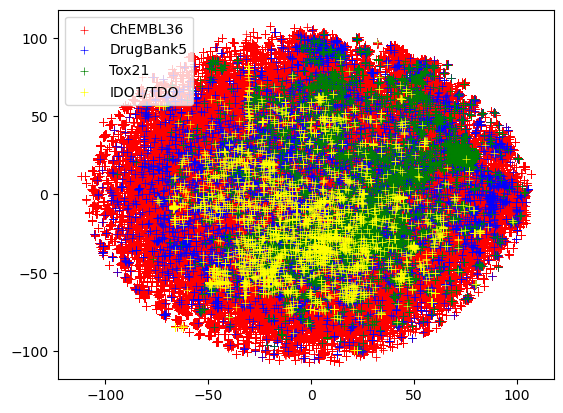

In [43]:
plt.figure()
sns.scatterplot(
    x=init_full[:, 0],
    y=init_full[:, 1],
    color='red',
    marker='+',
    label='ChEMBL36'
)
sns.scatterplot(
    x=X4_embedding[:, 0],
    y=X4_embedding[:, 1],
    color='blue',
    marker='+',
    label='DrugBank5'
)
sns.scatterplot(
    x=X2_embedding[:, 0],
    y=X2_embedding[:, 1],
    color='green',
    marker='+',
    label='Tox21'
)
sns.scatterplot(
    x=X1_embedding[:, 0],
    y=X1_embedding[:, 1],
    color='yellow',
    marker='+',
    label='IDO1/TDO'
)
plt.legend()
plt.show()


In [46]:
tsne = TSNE(
    perplexity=50,
    metric="cosine",
    initialization='pca',
    n_jobs=16,
    random_state=42,
    n_iter=500,
    verbose=True,
)

In [47]:
#Embeddings of DrugBank
%time embedding_train = tsne.fit(X4)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, metric='cosine', n_jobs=16, perplexity=50,
     random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 150 nearest neighbors using Annoy approximate search using cosine distance...
   --> Time elapsed: 10.00 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.19 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.26 seconds
===> Running optimization with exaggeration=12.00, lr=1217.17 for 250 iterations...
Iteration   50, KL divergence 5.3144, 50 iterations in 1.0136 sec
Iteration  100, KL divergence 5.3178, 50 iterations in 1.1163 sec
Iteration  150, KL divergence 5.3177, 50 iterations in 0.9930 sec
Iteration  200, KL divergence 5.3177, 50 iterations in 0.9818 sec
Iteration  250, KL divergence 5.3177, 50 iterations in 0.9833 sec
   --> Time elapsed: 5.09 seconds
===> Run

In [48]:
embedding_train.shape

(14606, 2)

In [49]:
#Transforming embeddings of Tox21
%time embedding_test_X2 = embedding_train.transform(X2)

===> Finding 15 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 2.98 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 0 iterations...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=1.50, lr=0.10 for 250 iterations...
Iteration   50, KL divergence 103035.4685, 50 iterations in 1.1825 sec
Iteration  100, KL divergence 101588.0531, 50 iterations in 1.1527 sec
Iteration  150, KL divergence 101084.4916, 50 iterations in 1.2659 sec
Iteration  200, KL divergence 100808.6319, 50 iterations in 1.1727 sec
Iteration  250, KL divergence 100646.2292, 50 iterations in 1.1569 sec
   --> Time elapsed: 5.93 seconds
CPU times: user 42.1 s, sys: 1.43 s, total: 43.6 s
Wall time: 8.99 s


In [50]:
embedding_test_X2.shape

(7830, 2)

In [51]:
#Transforming embeddings of IDO/TDO dataset
%time embedding_test_X1 = embedding_train.transform(X1)

===> Finding 15 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 1.83 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 0 iterations...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=1.50, lr=0.10 for 250 iterations...
Iteration   50, KL divergence 66745.1410, 50 iterations in 1.0272 sec
Iteration  100, KL divergence 64950.4626, 50 iterations in 0.9730 sec
Iteration  150, KL divergence 64309.9239, 50 iterations in 1.0440 sec
Iteration  200, KL divergence 64001.3412, 50 iterations in 0.9811 sec
Iteration  250, KL divergence 63823.9007, 50 iterations in 0.9918 sec
   --> Time elapsed: 5.02 seconds
CPU times: user 26.9 s, sys: 1.02 s, total: 28 s
Wall time: 6.9 s


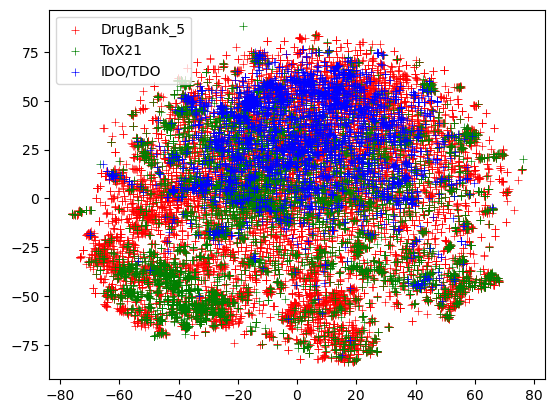

In [52]:
plt.figure()
sns.scatterplot(
    x=embedding_train[:, 0],
    y=embedding_train[:, 1],
    color='red',
    marker='+',
    label='DrugBank_5'
)
sns.scatterplot(
    x=embedding_test_X2[:, 0],
    y=embedding_test_X2[:, 1],
    color='green',
    marker='+',
    label='ToX21'
)
sns.scatterplot(
    x=embedding_test_X1[:, 0],
    y=embedding_test_X1[:, 1],
    color='blue',
    marker='+',
    label='IDO/TDO'
)
plt.legend()
plt.show()
